Saving customer_churn_dataset.csv to customer_churn_dataset.csv
First 5 Rows


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Female,0,Yes,No,52,Yes,Fiber optic,One year,106.70,5548.40,No
1,CUST00002,Male,0,Yes,Yes,15,No,DSL,One year,60.80,912.00,No
2,CUST00003,Female,0,Yes,Yes,72,Yes,DSL,Month-to-month,75.17,5412.24,No
3,CUST00004,Male,0,No,Yes,61,Yes,DSL,Month-to-month,45.39,2768.79,No
4,CUST00005,Male,0,No,Yes,21,Yes,Fiber optic,Month-to-month,39.61,831.81,Yes



Dataset Shape
(1000, 12)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       1000 non-null   object 
 1   gender           1000 non-null   object 
 2   SeniorCitizen    1000 non-null   int64  
 3   Partner          1000 non-null   object 
 4   Dependents       1000 non-null   object 
 5   tenure           1000 non-null   int64  
 6   PhoneService     1000 non-null   object 
 7   InternetService  1000 non-null   object 
 8   Contract         1000 non-null   object 
 9   MonthlyCharges   1000 non-null   float64
 10  TotalCharges     1000 non-null   float64
 11  Churn            1000 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 93.9+ KB

Missing Values
customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
Phone

/tmp/ipykernel_1870/3516366229.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


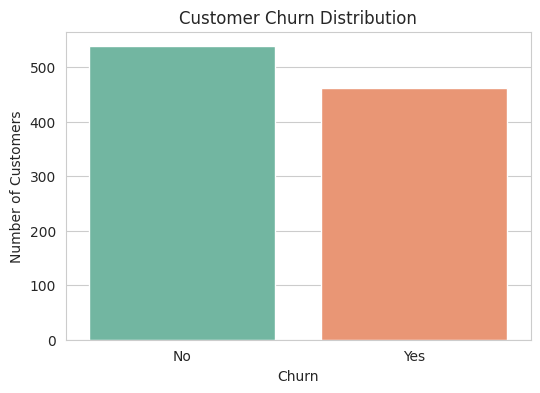

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.135000,35.881000,70.154370,2475.083670
std,0.341895,20.958915,28.637909,1832.083897
min,0.000000,1.000000,20.020000,24.420000
25%,0.000000,17.750000,45.297500,1040.042500
50%,0.000000,35.500000,71.330000,2102.800000
75%,0.000000,54.000000,94.637500,3511.372500
max,1.000000,72.000000,119.940000,8300.160000


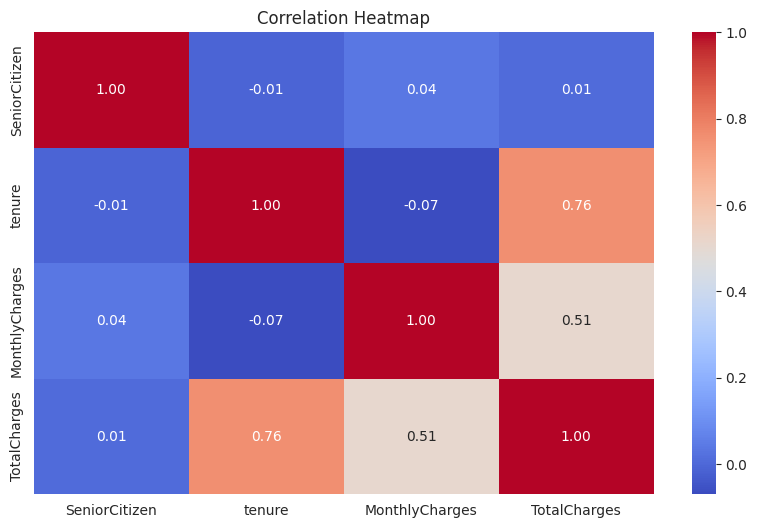

/tmp/ipykernel_1870/3516366229.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


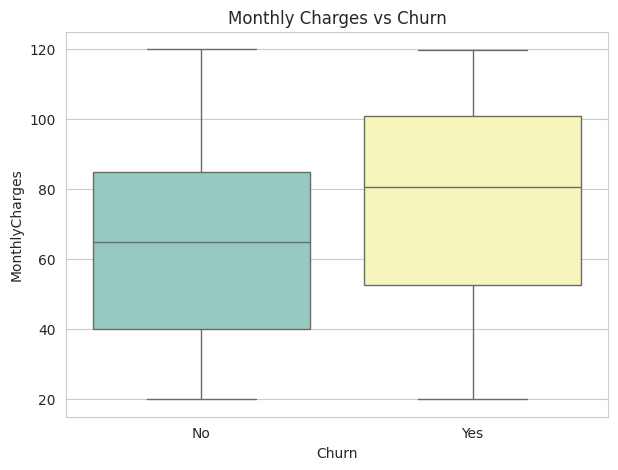

/tmp/ipykernel_1870/3516366229.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


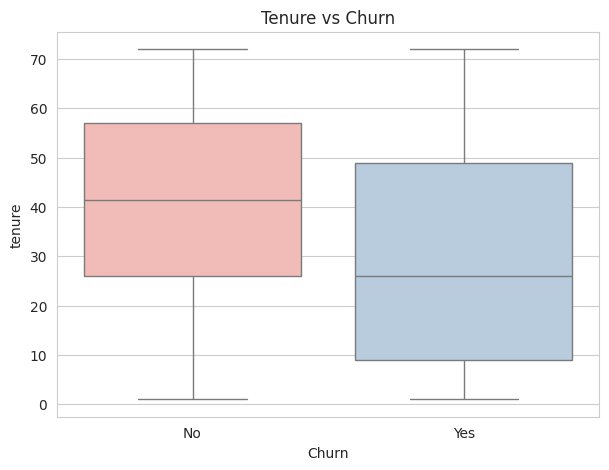

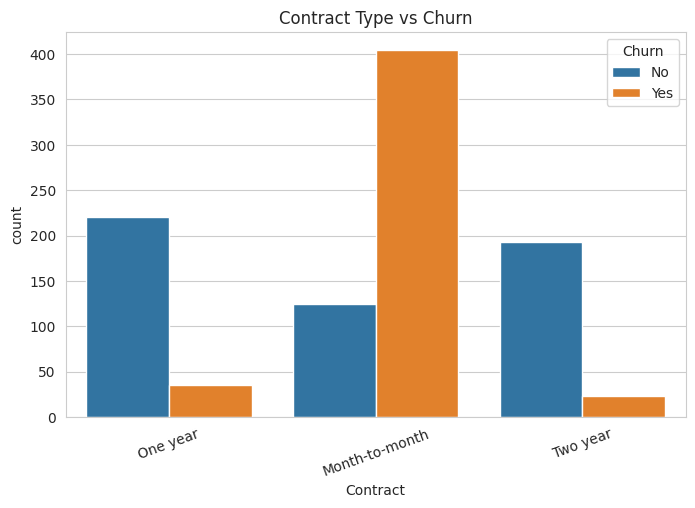

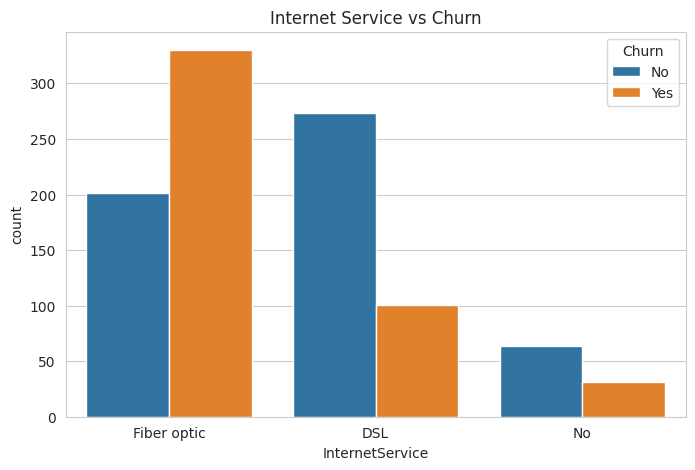


Customer Churn Percentage
Churn
No     53.8
Yes    46.2
Name: proportion, dtype: float64

========== PROJECT INSIGHTS ==========
✔ Customers with shorter tenure are more likely to churn.
✔ Higher monthly charges often increase churn probability.
✔ Month-to-month contracts usually experience higher churn.
✔ Long-term customers tend to stay with the company.
✔ Customer engagement and service quality influence retention.


In [2]:
# ==========================================
# CUSTOMER CHURN ANALYSIS
# ==========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Style
sns.set_style("whitegrid")

# ------------------------------------------
# Load Dataset
# ------------------------------------------

# Upload your CSV file in Colab first
from google.colab import files
uploaded = files.upload()

# Replace filename if needed
df = pd.read_csv(next(iter(uploaded)))

# ------------------------------------------
# Basic Information
# ------------------------------------------

print("First 5 Rows")
display(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Info")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

# ------------------------------------------
# Data Cleaning
# ------------------------------------------

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numerical values
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill missing categorical values
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

print("\nData Cleaned Successfully!")

# ------------------------------------------
# Churn Distribution
# ------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette='Set2')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

# ------------------------------------------
# Numerical Summary
# ------------------------------------------

display(df.describe())

# ------------------------------------------
# Correlation Heatmap
# ------------------------------------------

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# ------------------------------------------
# Monthly Charges vs Churn
# ------------------------------------------

if 'MonthlyCharges' in df.columns:

    plt.figure(figsize=(7,5))

    sns.boxplot(
        x='Churn',
        y='MonthlyCharges',
        data=df,
        palette='Set3'
    )

    plt.title("Monthly Charges vs Churn")
    plt.show()

# ------------------------------------------
# Tenure vs Churn
# ------------------------------------------

if 'tenure' in df.columns:

    plt.figure(figsize=(7,5))

    sns.boxplot(
        x='Churn',
        y='tenure',
        data=df,
        palette='Pastel1'
    )

    plt.title("Tenure vs Churn")
    plt.show()

# ------------------------------------------
# Contract Type Analysis
# ------------------------------------------

if 'Contract' in df.columns:

    plt.figure(figsize=(8,5))

    sns.countplot(
        x='Contract',
        hue='Churn',
        data=df
    )

    plt.title("Contract Type vs Churn")
    plt.xticks(rotation=20)
    plt.show()

# ------------------------------------------
# Internet Service Analysis
# ------------------------------------------

if 'InternetService' in df.columns:

    plt.figure(figsize=(8,5))

    sns.countplot(
        x='InternetService',
        hue='Churn',
        data=df
    )

    plt.title("Internet Service vs Churn")
    plt.show()

# ------------------------------------------
# Churn Percentage
# ------------------------------------------

churn_percent = df['Churn'].value_counts(normalize=True) * 100

print("\nCustomer Churn Percentage")
print(churn_percent.round(2))

# ------------------------------------------
# Key Insights
# ------------------------------------------

print("\n========== PROJECT INSIGHTS ==========")

print("✔ Customers with shorter tenure are more likely to churn.")
print("✔ Higher monthly charges often increase churn probability.")
print("✔ Month-to-month contracts usually experience higher churn.")
print("✔ Long-term customers tend to stay with the company.")
print("✔ Customer engagement and service quality influence retention.")